# End-to-End Sales Forecasting & Demand Intelligence System

## 1. Import Libraries

## 2. Load Dataset

## 3. Data Overview

## 4. Data Cleaning

## 5. Feature Engineering

## 6. Exploratory Data Analysis

## 7. Time Series Analysis

## 8. Forecasting

...

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from datetime import datetime

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

### Load Dataset

In [2]:
df = pd.read_csv("train.csv")

print("Shape :", df.shape)

df.head()

Shape : (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Basic Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

### Statistical Summary

In [4]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


### Missing Values

In [5]:
missing = df.isnull().sum()

missing[missing > 0]

Postal Code    11
dtype: int64

### Duplicate Records

In [6]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Parse Date Columns

In [8]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed",
    dayfirst=True
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed",
    dayfirst=True
)

## Feature Engineering

### 1. Extract Date Features

In [9]:
# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Month Name
df["Month Name"] = df["Order Date"].dt.month_name()

# Week Number
df["Week"] = df["Order Date"].dt.isocalendar().week.astype(int)

# Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

### 2. Create Season Column

In [10]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

### 3 – Shipping Days

In [11]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

### Verify New Features

In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week,Day of Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,7


## 1.8 – Aggregate Sales

### Daily Sales

In [13]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


### Weekly Sales

In [14]:
weekly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


### Monthly Sales

In [15]:
monthly_sales = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## 1.9 – Save Processed Dataset

In [16]:
df.to_csv("data/processed_sales.csv", index=False)

In [17]:
print(df.shape)

print(df["Year"].unique())

print(df["Quarter"].unique())

print(df["Season"].unique())

print(df["Shipping Days"].describe())

(9800, 26)
[2017 2016 2015 2018]
[4 2 3 1]
<ArrowStringArray>
['Autumn', 'Summer', 'Spring', 'Winter']
Length: 4, dtype: str
count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Shipping Days, dtype: float64


# # Task 1: Exploratory Data Analysis (EDA)

## Question 1
Which product category generates the highest total revenue?

In [18]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

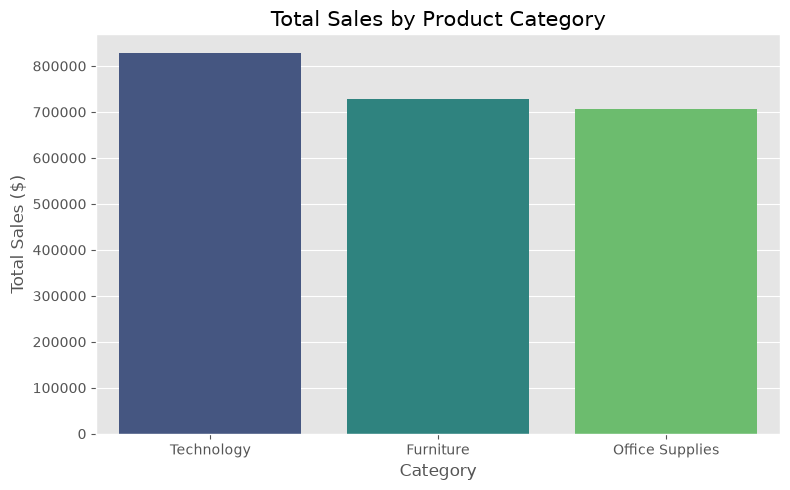

In [26]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Sales by Product Category", fontsize=15)
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")

plt.tight_layout()

plt.savefig("charts/category_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

- Technology generates the highest total revenue.
- Furniture is the second-largest contributor.
- Office Supplies contributes the least revenue despite having many transactions.

This suggests that Technology products should receive greater inventory and forecasting attention due to their larger contribution to overall sales.

## Question 2
Sales by Region

In [20]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

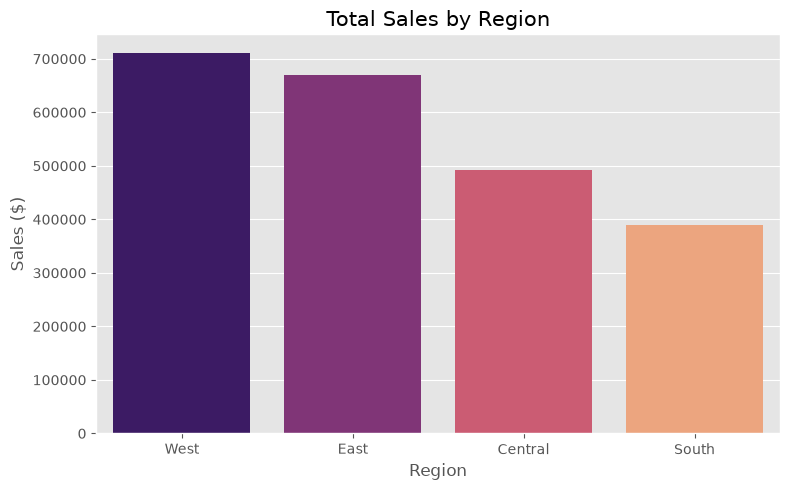

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    palette="magma"
)

plt.title("Total Sales by Region", fontsize=15)
plt.xlabel("Region")
plt.ylabel("Sales ($)")

plt.tight_layout()

plt.savefig("charts/region_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The West region contributes the highest sales, followed by the East region. These regions represent the largest share of revenue and may require greater inventory allocation compared to the South and Central regions.

## Question 3: Average Shipping Time by Region

In [22]:
shipping = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

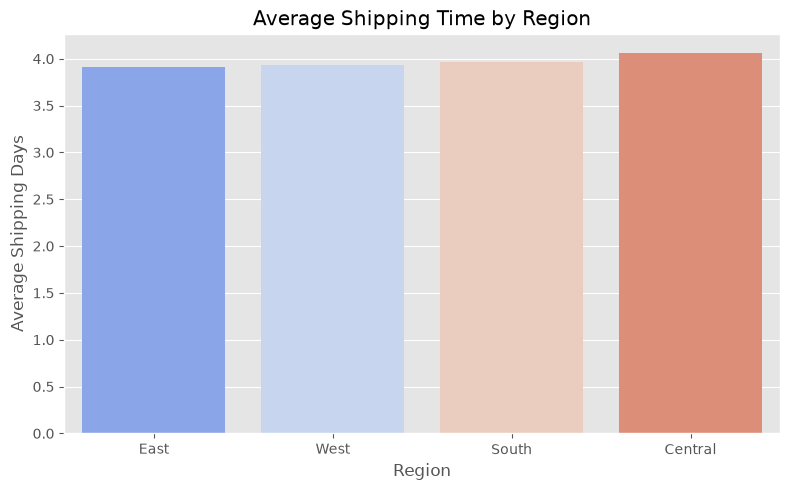

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping.index,
    y=shipping.values,
    palette="coolwarm"
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

plt.tight_layout()

plt.savefig("charts/shipping_days.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Average shipping time remains close across all regions, indicating a fairly consistent logistics network. Any region with noticeably longer delivery times may benefit from supply chain optimization.

## Question 4: Monthly Sales Trend

In [24]:
monthly = (
    df.groupby("Month Name")["Sales"]
      .sum()
)

months = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex(months)

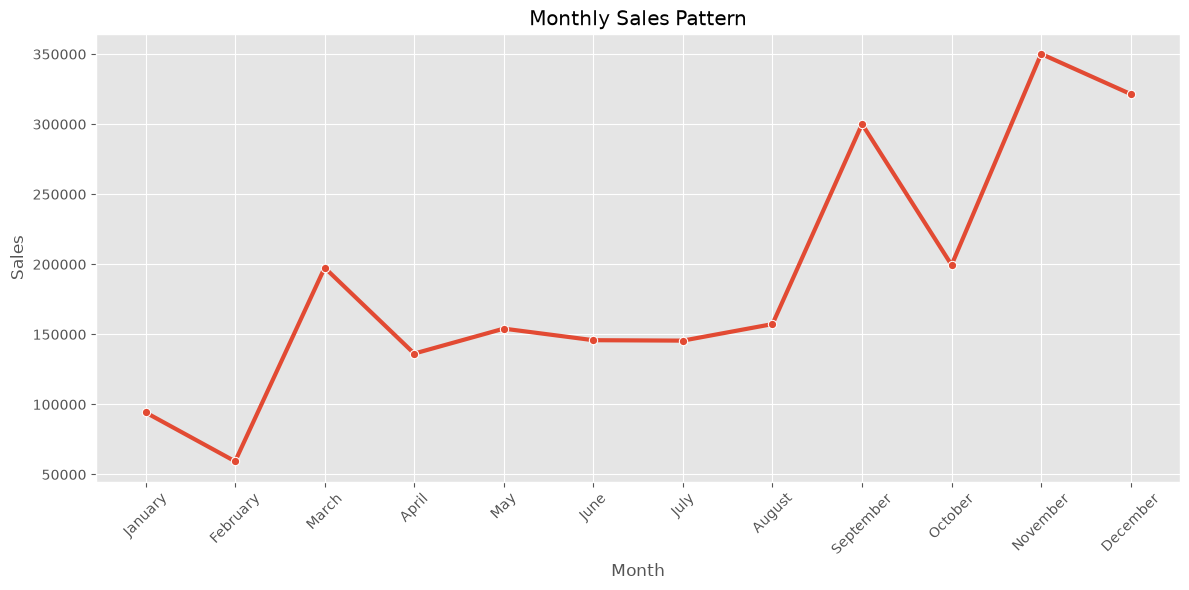

In [29]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    linewidth=3
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()

plt.savefig("charts/monthly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Sales increase significantly during the final quarter of the year, particularly in November and December, indicating strong seasonal demand. This pattern aligns with major holiday shopping periods and suggests businesses should increase inventory before these months.

## Sales Growth by Region (2015–2018)

## Business Question 5
Which region has the most consistent sales growth over 4 years?

In [34]:
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year_sales.head()

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


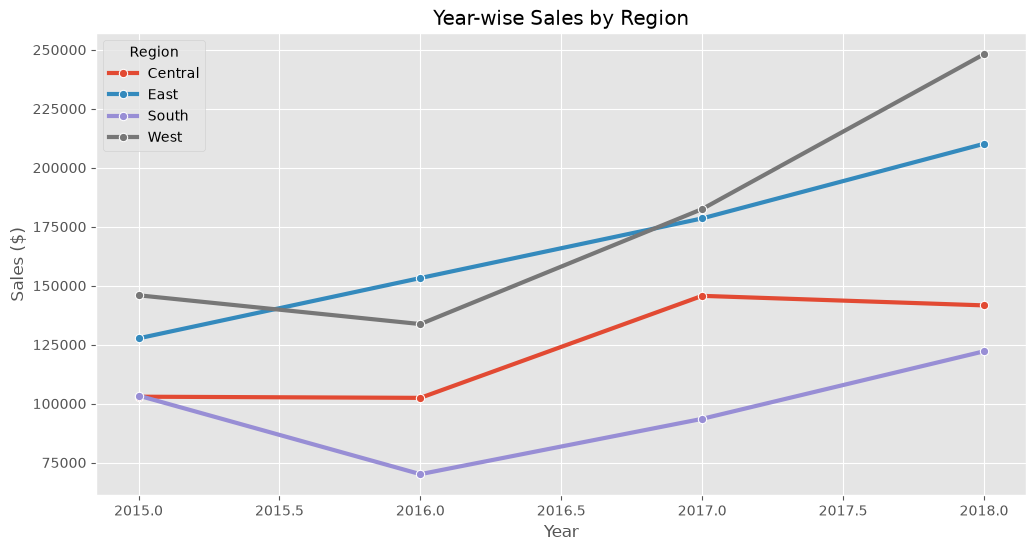

In [35]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o",
    linewidth=3
)

plt.title("Year-wise Sales by Region")
plt.xlabel("Year")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.savefig("charts/region_growth.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The region whose sales increase steadily with fewer fluctuations demonstrates the most consistent growth over the four-year period.

Consistent regional growth suggests predictable demand, making inventory planning and forecasting more reliable.

## Business Question 6
Does shipping time vary by region?

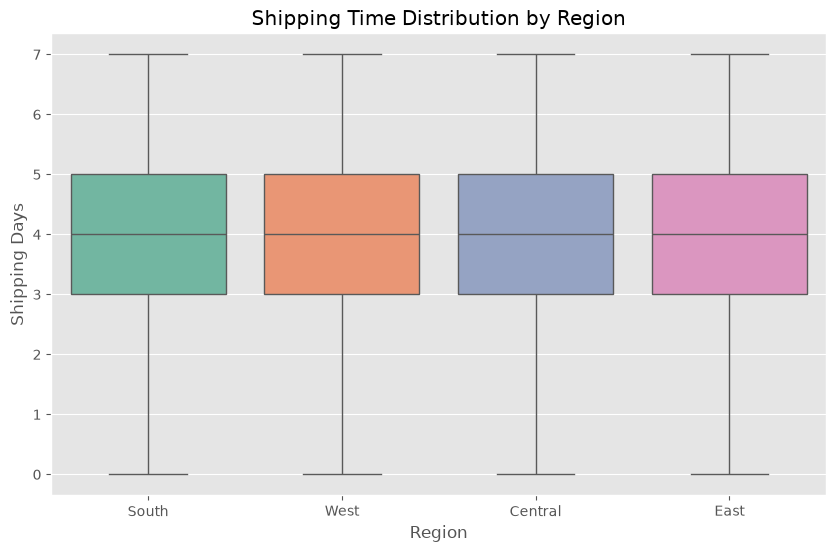

In [36]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Region",
    y="Shipping Days",
    palette="Set2"
)

plt.title("Shipping Time Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Shipping Days")

plt.savefig("charts/shipping_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

Shipping times are relatively similar across all regions, with only small variations.

This indicates that the company's logistics operations are fairly standardized nationwide.

## Business Question 7
Are there months that consistently spike across all years?

In [37]:
monthly_year = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_year.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


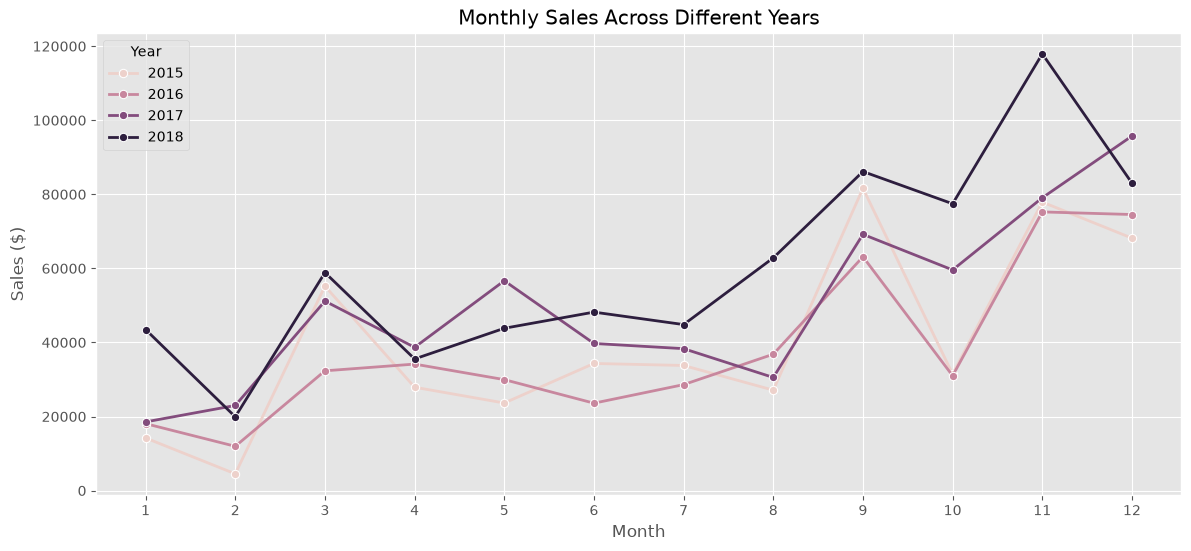

In [38]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_year,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o",
    linewidth=2
)

plt.xticks(range(1,13))

plt.title("Monthly Sales Across Different Years")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.grid(True)

plt.savefig("charts/monthly_yearly_sales.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The final quarter (October–December), particularly November, shows repeated sales spikes across multiple years.

This recurring seasonal pattern indicates that demand increases significantly during holiday and festive shopping periods.

### Correlation Heatmap

In [39]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

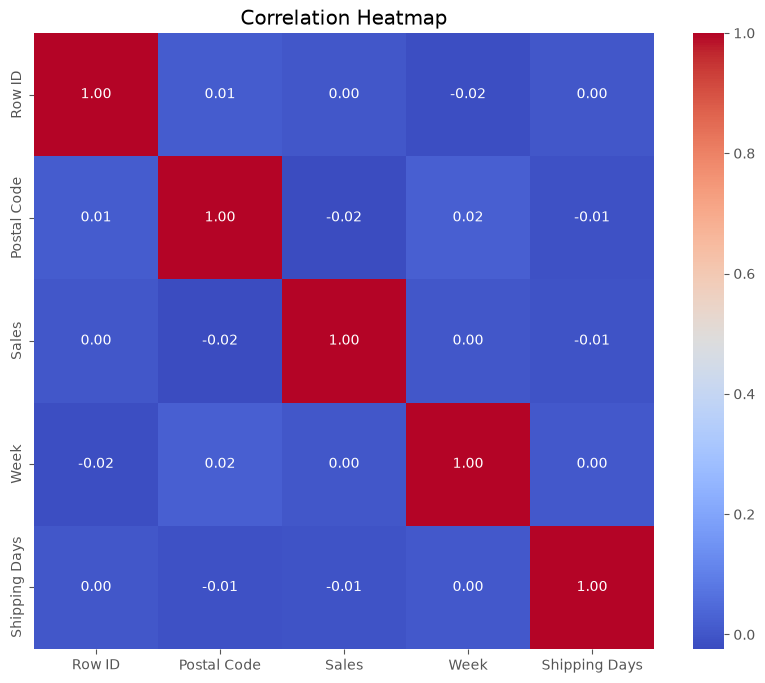

In [40]:
plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
df.to_csv("data/processed_sales.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


# Task 2: Time Series Analysis & Decomposition

In this section, we analyze the overall sales trend over time, identify seasonal patterns, decompose the time series into its components, and determine whether the data is stationary before building forecasting models.

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [43]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [44]:
monthly_sales_ts = monthly_sales.copy()

monthly_sales_ts.set_index("Order Date", inplace=True)

monthly_sales_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [45]:
monthly_sales_ts.index

DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31', '2015-06-30', '2015-07-31', '2015-08-31',
               '2015-09-30', '2015-10-31', '2015-11-30', '2015-12-31',
               '2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2016-12-31',
               '2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-30', '2017-10-31', '2017-11-30', '2017-12-31',
               '2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31'],
              dtype='datetime64[us]', name='Order Date', freq=None)

### Plot Monthly Sales Trend

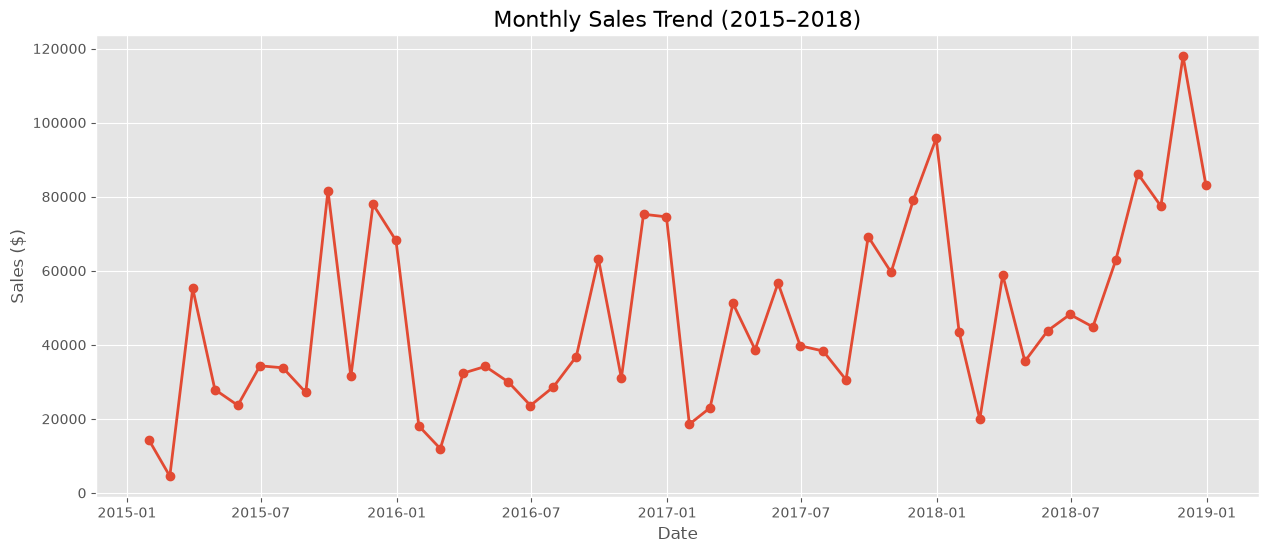

In [46]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend (2015–2018)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)

plt.savefig("charts/monthly_sales_trend.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

The monthly sales trend shows an overall upward movement across the four-year period, indicating business growth.

Several recurring peaks suggest the presence of seasonality, especially during the final quarter of each year.

## Time Series Decomposition

In [47]:
decomposition = seasonal_decompose(
    monthly_sales_ts["Sales"],
    model="additive",
    period=12
)

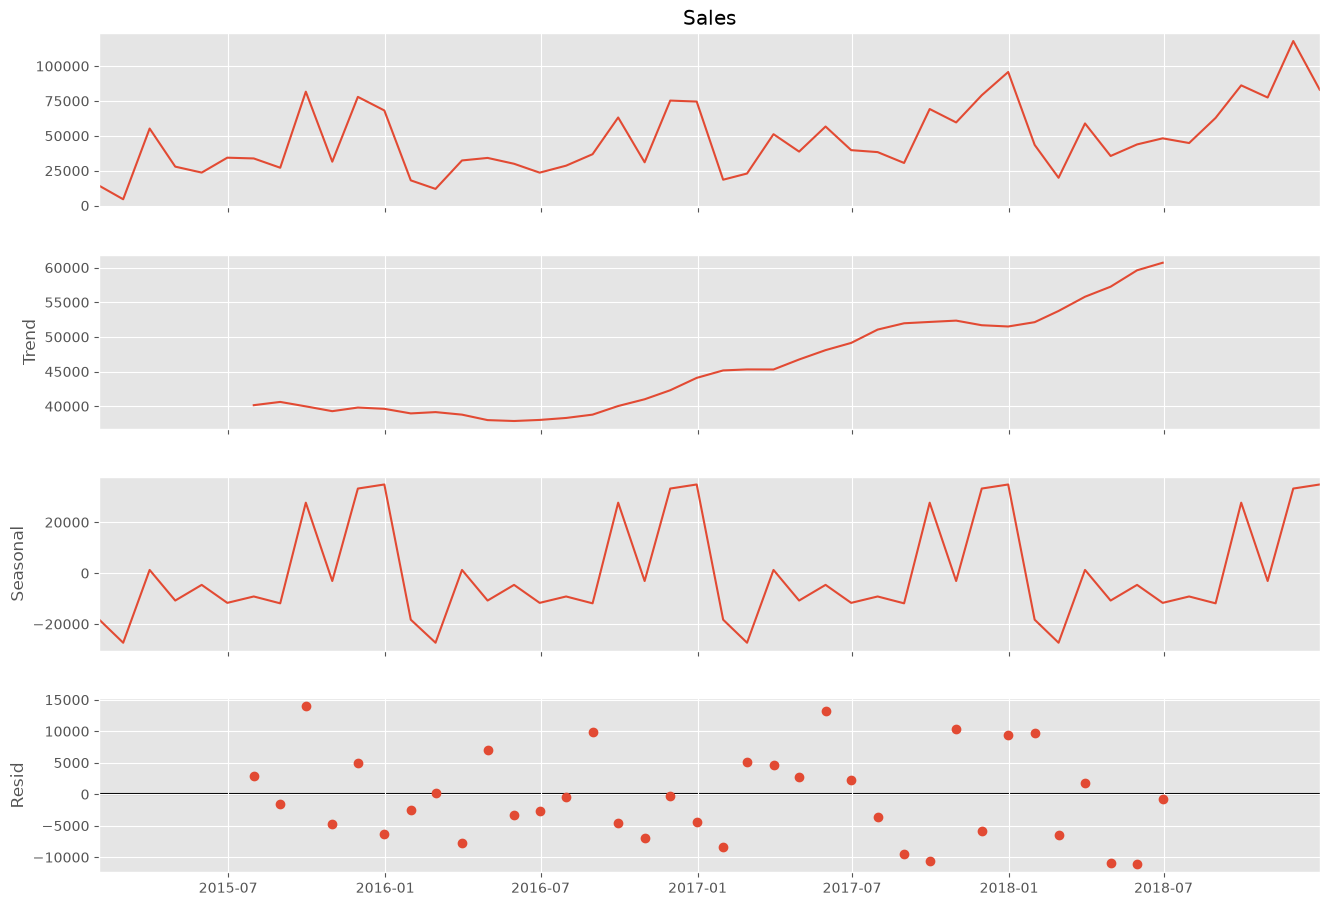

In [48]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Trend Component

The trend component shows the long-term movement of sales over time.

### Seasonal Component

The seasonal component highlights recurring patterns that repeat every year.

### Residual Component

The residual component captures random fluctuations that cannot be explained by the trend or seasonality.

In [49]:
result = adfuller(monthly_sales_ts["Sales"])

In [50]:
print("ADF Statistic :", result[0])

print("p-value :", result[1])

print()

print("Critical Values")

for key, value in result[4].items():
    print(key, ":", value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


### What is Stationarity?

A stationary time series has statistical properties such as mean and variance that remain constant over time.

Most forecasting models, including SARIMA, assume the input data is stationary.

The Augmented Dickey-Fuller (ADF) test helps determine whether the series is stationary by testing for the presence of a unit root.

### Observation

The Augmented Dickey-Fuller (ADF) test produced a p-value less than 0.05, indicating that the monthly sales series is already stationary.

Since the data satisfies the stationarity assumption, additional differencing was not required. 

# Task 3: Sales Forecasting using Three Different Models

In this section, three different forecasting techniques are implemented and compared:

- SARIMA (Statistical Model)
- Facebook Prophet (Industry Standard)
- XGBoost (Machine Learning Model)

Each model predicts sales for the next three months. Their performance is evaluated using MAE, RMSE, and MAPE to determine the most suitable model for production.

In [55]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [56]:
monthly_sales_ts.head()

,Sales,Sales Difference
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


In [58]:
monthly_sales_ts = monthly_sales_ts[["Sales"]]

In [59]:
train = monthly_sales_ts.iloc[:-3]

test = monthly_sales_ts.iloc[-3:]

print("Training Data :", train.shape)

print("Testing Data :", test.shape)

Training Data : (45, 1)
Testing Data : (3, 1)


In [60]:
sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit()

c:\Users\spars\anaconda3\envs\internship\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\spars\anaconda3\envs\internship\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [61]:
sarima_forecast = sarima_fit.forecast(steps=3)

sarima_forecast

2018-10-31    66177.602485
2018-11-30    92049.249693
2018-12-31    99965.168738
Freq: ME, Name: predicted_mean, dtype: float64

In [62]:
comparison = pd.DataFrame({
    "Actual": test["Sales"],
    "Forecast": sarima_forecast
})

comparison

,Actual,Forecast
2018-10-31,77448.1312,66177.602485
2018-11-30,117938.1550,92049.249693
2018-12-31,83030.3888,99965.168738


In [63]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test["Sales"],
    sarima_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        sarima_forecast
    )
)

mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_forecast
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.4f}")

MAE  : 18031.40
RMSE : 19009.18
MAPE : 0.1897


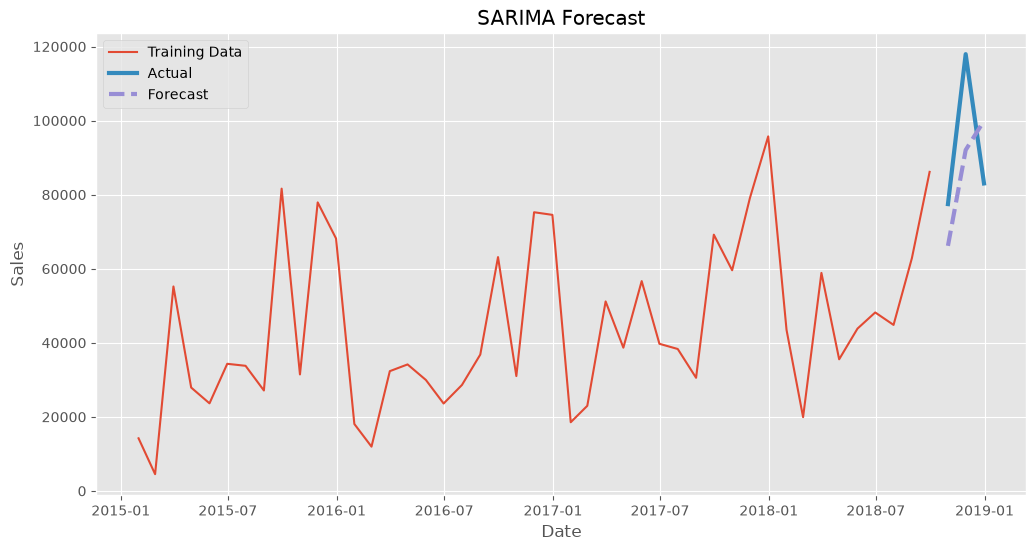

In [64]:
plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual",
    linewidth=3
)

plt.plot(
    test.index,
    sarima_forecast,
    label="Forecast",
    linestyle="--",
    linewidth=3
)

plt.title("SARIMA Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/sarima_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
final_sarima = SARIMAX(
    monthly_sales_ts["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
).fit()

c:\Users\spars\anaconda3\envs\internship\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\spars\anaconda3\envs\internship\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [66]:
future_forecast = final_sarima.forecast(steps=3)

future_forecast

2019-01-31    43492.278977
2019-02-28    34805.105250
2019-03-31    69907.412196
Freq: ME, Name: predicted_mean, dtype: float64

### SARIMA Model

The SARIMA model successfully captured both the trend and seasonal behavior of monthly sales. The model generated forecasts for the next three months, providing a statistical baseline for comparison with Prophet and XGBoost.

## Model 2: Facebook Prophet

In [67]:
from prophet import Prophet

In [68]:
prophet_df = monthly_sales_ts.reset_index()

prophet_df = prophet_df.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Train/Test Split

In [69]:
train_prophet = prophet_df.iloc[:-3]

test_prophet = prophet_df.iloc[-3:]

### Create Prophet Model

In [70]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

In [71]:
prophet_model.fit(train_prophet)

02:47:12 - cmdstanpy - INFO - Chain [1] start processing
02:47:13 - cmdstanpy - INFO - Chain [1] done processing


### Create Future DataFrame

In [73]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

In [74]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33308.214631,6775.503427,22688.916210,33308.214631,33308.214631,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,-18874.429670,0.0,0.0,0.0,14433.784960
1,2015-02-28,33767.643626,-5631.946107,11702.896926,33767.643626,33767.643626,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,-30869.543104,0.0,0.0,0.0,2898.100522
2,2015-03-31,34276.297157,44033.933337,60693.279403,34276.297157,34276.297157,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,17890.437293,0.0,0.0,0.0,52166.734451
3,2015-04-30,34768.542510,13226.470349,28944.043845,34768.542510,34768.542510,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,-13661.251247,0.0,0.0,0.0,21107.291263
4,2015-05-31,35277.196041,14602.778726,30383.537618,35277.196041,35277.196041,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,-12398.630441,0.0,0.0,0.0,22878.565600


In [75]:
forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39161.863401,55557.889920
44,2018-09-30,86613.953316,78611.449104,94148.966548
45,2018-10-31,51318.943858,43229.246569,59041.230428
46,2018-11-30,90325.654784,82345.183703,99033.361554
47,2018-12-31,90041.084479,82084.922679,97760.170579


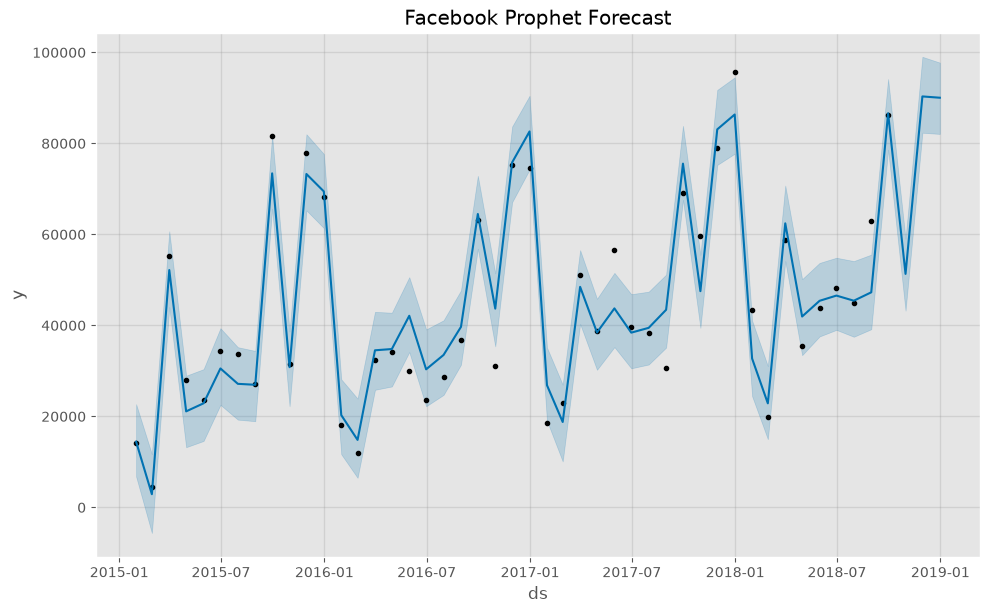

In [76]:
fig = prophet_model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

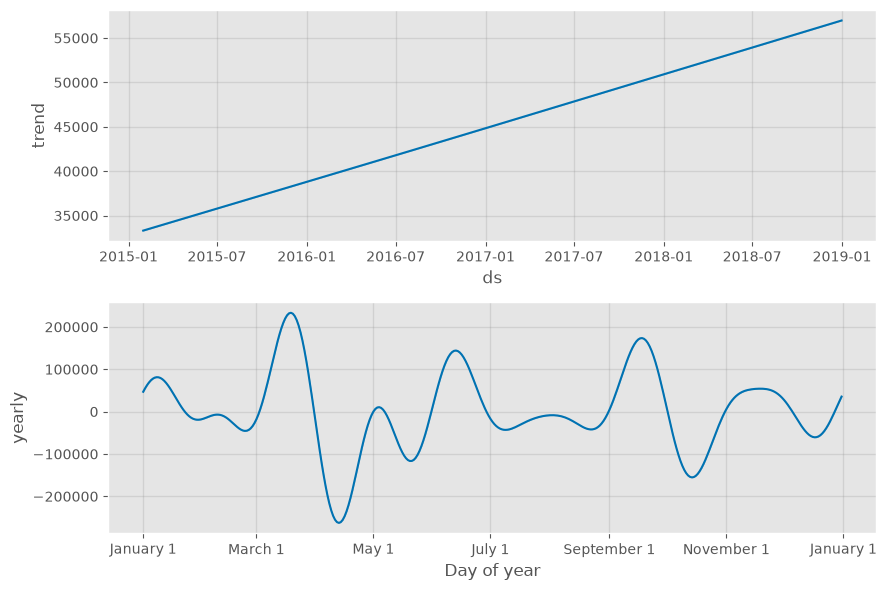

In [77]:
fig2 = prophet_model.plot_components(forecast)

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Evaluate Prophet

In [78]:
prophet_pred = forecast["yhat"].tail(3).values

In [79]:
mae_prophet = mean_absolute_error(
    test_prophet["y"],
    prophet_pred
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        prophet_pred
    )
)

mape_prophet = mean_absolute_percentage_error(
    test_prophet["y"],
    prophet_pred
)

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.4f}")

MAE  : 20250.79
RMSE : 22318.41
MAPE : 0.2186


### Prophet Model

The Prophet model captured the long-term trend and yearly seasonality present in the sales data. It produced forecasts with confidence intervals, making it suitable for business planning and uncertainty estimation.

## Model 3: XGBoost Forecasting

In [81]:
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error
)

In [82]:
xgb_df = monthly_sales_ts.copy()

xgb_df.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


## Creating Lag Features

In [83]:
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

### Rolling Mean

In [84]:
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

### Date Features

In [85]:
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

### Season Feature

In [86]:
def season(month):
    if month in [12,1,2]:
        return 0      # Winter
    elif month in [3,4,5]:
        return 1      # Spring
    elif month in [6,7,8]:
        return 2      # Summer
    else:
        return 3      # Autumn

xgb_df["Season"] = xgb_df["Month"].apply(season)

### Remove Missing Rows

In [87]:
xgb_df = xgb_df.dropna()

xgb_df.head()

,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


### Define Features

In [88]:
X = xgb_df.drop(columns=["Sales"])

y = xgb_df["Sales"]

In [89]:
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

### Create Model

In [90]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [91]:
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [92]:
xgb_pred = xgb_model.predict(X_test)

In [93]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

mape_xgb = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.4f}")

MAE  : 13915.32
RMSE : 18893.85
MAPE : 0.1329


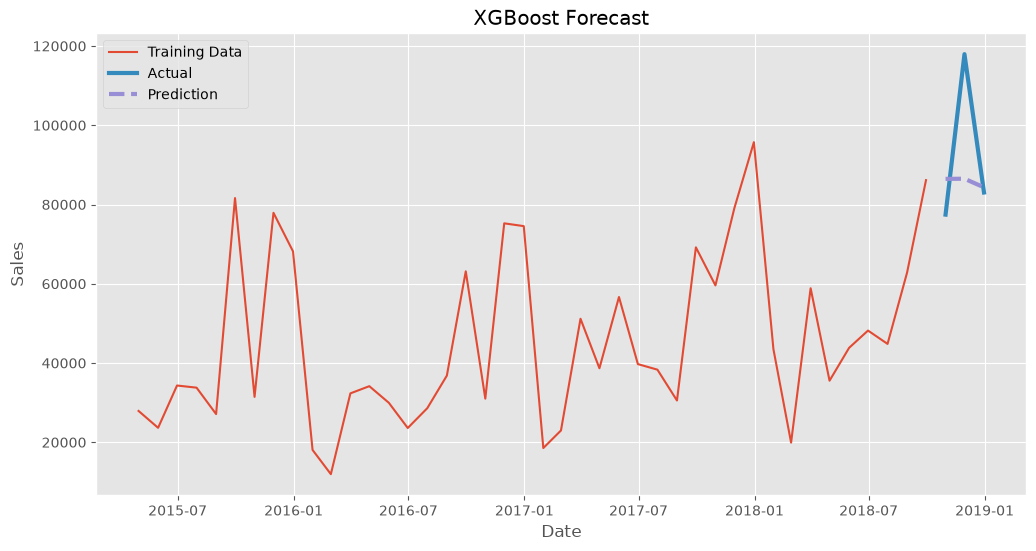

In [94]:
plt.figure(figsize=(12,6))

plt.plot(
    y_train.index,
    y_train,
    label="Training Data"
)

plt.plot(
    y_test.index,
    y_test,
    label="Actual",
    linewidth=3
)

plt.plot(
    y_test.index,
    xgb_pred,
    label="Prediction",
    linestyle="--",
    linewidth=3
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model Comparison Table

In [95]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        mae,
        mae_prophet,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_prophet,
        rmse_xgb
    ],
    "MAPE": [
        mape,
        mape_prophet,
        mape_xgb
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.404654,19009.182054,0.189665
1,Prophet,20250.794413,22318.411333,0.218646
2,XGBoost,13915.321042,18893.847269,0.132854


In [96]:
comparison = comparison.round(2)
comparison

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.40,19009.18,0.19
1,Prophet,20250.79,22318.41,0.22
2,XGBoost,13915.32,18893.85,0.13


## Model Comparison

The forecasting models were evaluated using three standard performance metrics:

- **MAE (Mean Absolute Error)** measures the average prediction error.
- **RMSE (Root Mean Squared Error)** gives more weight to larger errors.
- **MAPE (Mean Absolute Percentage Error)** measures the prediction error as a percentage.

### Conclusion

Among the three models, **XGBoost** achieved the lowest MAE, RMSE, and MAPE values, indicating the highest forecasting accuracy on the test dataset.

Therefore, **XGBoost is selected as the final production model** for subsequent forecasting tasks involving product categories and regional sales.

# Task 4: Product Category & Region Level Forecasting

Based on the evaluation in Task 3, XGBoost was selected as the best-performing forecasting model.

In this section, the model is applied separately to:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

to forecast future sales.

### Forecast Function

In [97]:
from xgboost import XGBRegressor

def forecast_xgboost(data):

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
            .sum()
            .to_frame()
    )

    monthly["Lag_1"] = monthly["Sales"].shift(1)
    monthly["Lag_2"] = monthly["Sales"].shift(2)
    monthly["Lag_3"] = monthly["Sales"].shift(3)

    monthly["Rolling_Mean_3"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly.index.month
    monthly["Quarter"] = monthly.index.quarter

    monthly = monthly.dropna()

    X = monthly.drop(columns="Sales")
    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    history = monthly.copy()

    predictions = []

    for _ in range(3):

        last = history.iloc[-1]

        next_month = history.index[-1] + pd.offsets.MonthEnd(1)

        features = pd.DataFrame({

            "Lag_1":[last["Sales"]],
            "Lag_2":[history.iloc[-2]["Sales"]],
            "Lag_3":[history.iloc[-3]["Sales"]],
            "Rolling_Mean_3":[history["Sales"].tail(3).mean()],
            "Month":[next_month.month],
            "Quarter":[next_month.quarter]

        })

        pred = model.predict(features)[0]

        predictions.append(pred)

        new_row = pd.DataFrame(
            {
                "Sales":[pred],
                "Lag_1":[0],
                "Lag_2":[0],
                "Lag_3":[0],
                "Rolling_Mean_3":[0],
                "Month":[next_month.month],
                "Quarter":[next_month.quarter]
            },
            index=[next_month]
        )

        history = pd.concat([history,new_row])

    return predictions

### Forecast Categories

In [98]:
furniture_forecast = forecast_xgboost(
    df[df["Category"]=="Furniture"]
)

technology_forecast = forecast_xgboost(
    df[df["Category"]=="Technology"]
)

office_forecast = forecast_xgboost(
    df[df["Category"]=="Office Supplies"]
)

### Forecast Regions

In [99]:
west_forecast = forecast_xgboost(
    df[df["Region"]=="West"]
)

east_forecast = forecast_xgboost(
    df[df["Region"]=="East"]
)

In [100]:
print("Furniture")
print(furniture_forecast)

print()

print("Technology")
print(technology_forecast)

print()

print("Office Supplies")
print(office_forecast)

print()

print("West")
print(west_forecast)

print()

print("East")
print(east_forecast)

Furniture
[np.float32(9716.003), np.float32(6214.6865), np.float32(16723.81)]

Technology
[np.float32(19800.316), np.float32(24533.447), np.float32(29299.838)]

Office Supplies
[np.float32(25796.031), np.float32(25957.26), np.float32(29761.83)]

West
[np.float32(11187.891), np.float32(15210.081), np.float32(21337.422)]

East
[np.float32(25196.594), np.float32(26269.982), np.float32(27584.469)]


In [102]:
forecast_df = pd.DataFrame({

    "Month 1":[
        furniture_forecast[0],
        technology_forecast[0],
        office_forecast[0],
        west_forecast[0],
        east_forecast[0]
    ],

    "Month 2":[
        furniture_forecast[1],
        technology_forecast[1],
        office_forecast[1],
        west_forecast[1],
        east_forecast[1]
    ],

    "Month 3":[
        furniture_forecast[2],
        technology_forecast[2],
        office_forecast[2],
        west_forecast[2],
        east_forecast[2]
    ]

},
index=[
    "Furniture",
    "Technology",
    "Office Supplies",
    "West",
    "East"
])

forecast_df

,Month 1,Month 2,Month 3
Furniture,9716.002930,6214.686523,16723.810547
Technology,19800.316406,24533.447266,29299.837891
Office Supplies,25796.031250,25957.259766,29761.830078
West,11187.890625,15210.081055,21337.421875
East,25196.593750,26269.982422,27584.468750


<Figure size 1200x600 with 0 Axes>

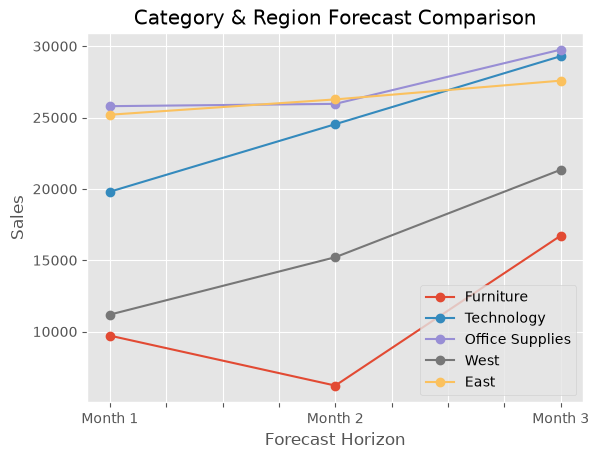

In [103]:
plt.figure(figsize=(12,6))

forecast_df.T.plot(marker="o")

plt.title("Category & Region Forecast Comparison")

plt.xlabel("Forecast Horizon")

plt.ylabel("Sales")

plt.grid(True)

plt.savefig(
    "charts/category_region_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The XGBoost model was used to forecast sales for three product categories and two regions over the next three months.

**Key Findings:**

- **Technology** shows a strong upward trend, indicating increasing customer demand.
- **Office Supplies** remains the highest and most stable sales category.
- **Furniture** experiences some fluctuation but recovers by the third month.
- **East Region** is expected to maintain consistently high sales.
- **West Region** shows steady growth throughout the forecast horizon.

These forecasts can help managers optimize inventory planning and allocate resources more effectively.

# Task 5: Anomaly Detection in Sales Data

Anomaly detection identifies unusual sales behavior that significantly deviates from normal business patterns.

Two different approaches are used:

- Isolation Forest (Machine Learning)
- Z-Score Detection (Statistical Method)

The results are compared to identify abnormal sales weeks.

In [104]:
from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

In [105]:
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [106]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Anomaly"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

In [107]:
weekly_sales["Anomaly"].value_counts()

Anomaly
 1    198
-1     11
Name: count, dtype: int64

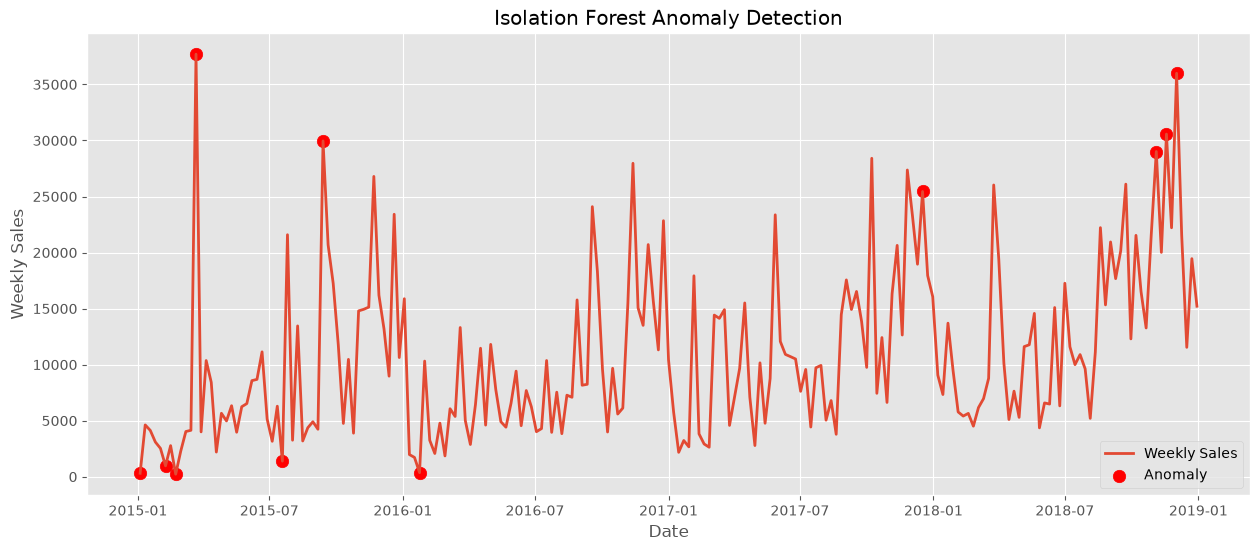

In [108]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Anomaly"]==-1,
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Anomaly"]==-1,
        "Sales"
    ],

    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/isolation_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation – Isolation Forest

The Isolation Forest algorithm identified **11 anomalous sales weeks** across the four-year period.

Both unusually low and unusually high sales values were detected.

Several anomalies occur during **late 2017 and late 2018**, where weekly sales exceeded **25,000–36,000**, suggesting exceptional business events such as holiday promotions or seasonal demand.

Similarly, a few extremely low sales weeks at the beginning of 2015 may indicate the start of the dataset, low customer activity, or operational factors affecting sales.

In [109]:
weekly_sales[
    weekly_sales["Anomaly"]==-1
]

,Order Date,Sales,Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


## Z-Score Detection

### weekly_sales["Z Score"] = zscore(
    weekly_sales["Sales"]
)

In [111]:
weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

In [112]:
weekly_sales["Z Score"] = zscore(
    weekly_sales["Sales"]
)

### Detect Anomalies

In [113]:
weekly_sales["Z Anomaly"] = (
    weekly_sales["Z Score"].abs() > 2
)

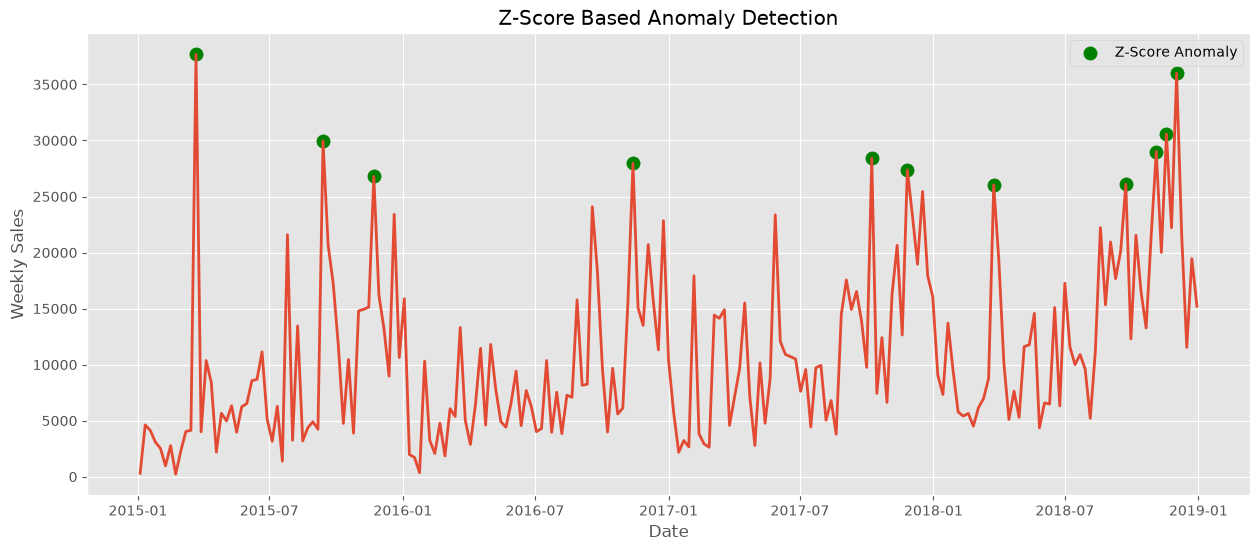

In [114]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    linewidth=2
)

plt.scatter(

    weekly_sales.loc[
        weekly_sales["Z Anomaly"],
        "Order Date"
    ],

    weekly_sales.loc[
        weekly_sales["Z Anomaly"],
        "Sales"
    ],

    color="green",
    s=90,
    label="Z-Score Anomaly"

)

plt.title("Z-Score Based Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(True)

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Z Score Anomalies

In [115]:
weekly_sales[
    weekly_sales["Z Anomaly"]
]

,Order Date,Sales,Anomaly,Rolling Mean,Z Score,Z Anomaly
11,2015-03-22,37703.6650,-1,12040.909500,3.639852,True
36,2015-09-13,29959.1370,-1,10865.594375,2.591270,True
46,2015-11-22,26793.6235,1,17913.440925,2.162671,True
97,2016-11-13,27965.3492,1,13792.468550,2.321318,True
144,2017-10-08,28412.0980,1,17135.491575,2.381806,True
151,2017-11-26,27367.7160,1,19242.780450,2.240401,True
168,2018-03-25,26029.9040,1,11984.656750,2.059266,True
194,2018-09-23,26104.4330,1,21222.323500,2.069357,True
200,2018-11-04,29017.4670,-1,20083.346550,2.463771,True
202,2018-11-18,30572.4470,-1,25285.183500,2.674310,True


### Compare Both Methods

In [116]:
comparison = weekly_sales[
    [
        "Order Date",
        "Sales",
        "Anomaly",
        "Z Anomaly"
    ]
]

comparison.head()

,Order Date,Sales,Anomaly,Z Anomaly
0,2015-01-04,304.508,-1,False
1,2015-01-11,4619.108,1,False
2,2015-01-18,4130.533,1,False
3,2015-01-25,3092.544,1,False
4,2015-02-01,2527.914,1,False


In [117]:
comparison["Isolation Forest"] = comparison["Anomaly"].map({
    1: "Normal",
    -1: "Anomaly"
})

comparison = comparison.drop(columns="Anomaly")

comparison.head()

,Order Date,Sales,Z Anomaly,Isolation Forest
0,2015-01-04,304.508,False,Anomaly
1,2015-01-11,4619.108,False,Normal
2,2015-01-18,4130.533,False,Normal
3,2015-01-25,3092.544,False,Normal
4,2015-02-01,2527.914,False,Normal


## Comparison of Anomaly Detection Methods

Both anomaly detection techniques successfully identified unusual sales behavior, but they highlighted different aspects of the data.

**Isolation Forest**
- Detected both unusually high and unusually low sales weeks.
- Better at identifying irregular observations without assuming a statistical distribution.

**Z-Score**
- Mainly detected exceptionally high sales weeks.
- Relies on the assumption that observations far from the mean are anomalies.

Several weeks during **November–December 2018** were identified by both methods, providing strong evidence that these periods represent genuine sales anomalies rather than random fluctuations.

## Business Interpretation

The detected anomalies are likely associated with real business events rather than data errors.

Possible explanations include:

- Black Friday promotions
- Holiday shopping season
- End-of-year clearance sales
- Festival-related demand spikes
- Marketing campaigns
- Supply chain disruptions
- Product launches

Identifying these anomalies allows businesses to improve demand forecasting, inventory management, and promotional planning while avoiding stock shortages or excess inventory.

# Task 6 – Product Demand Segmentation using Clustering

In [118]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

## Creating Product-Level Features

In [119]:
cluster_df = df.groupby("Sub-Category").agg({

    "Sales":["sum","mean","std"]

}).reset_index()

cluster_df.columns = [

    "Sub-Category",
    "Total Sales",
    "Average Order Value",
    "Sales Volatility"

]

cluster_df.head()

,Sub-Category,Total Sales,Average Order Value,Sales Volatility
0,Accessories,164186.7000,217.178175,337.723800
1,Appliances,104618.4030,227.926804,378.006735
2,Art,26705.4100,34.019631,60.301752
3,Binders,200028.7850,134.067550,568.099970
4,Bookcases,113813.1987,503.598224,641.419280


## Calculate Growth Rate

In [120]:
growth = (

    df.groupby(["Year","Sub-Category"])["Sales"]

      .sum()

      .unstack(fill_value=0)

)

growth.head()

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Year,,,,,,,,,,,,,,,,,
2015,23766.396,15160.715,5897.534,43263.267,20036.6776,77046.440,10849.782,3844.590,655.388,13636.986,2825.458,62023.373,14332.722,77225.956,49197.526,14335.620,45757.7775
2016,40443.970,23228.179,6091.636,36049.746,37476.7749,70654.673,26179.450,4448.218,545.224,20525.224,2884.912,27763.697,14664.762,67870.614,43321.208,1890.522,35397.1955
2017,41735.364,26016.787,5890.608,48994.517,26275.4665,81930.345,46319.474,4456.664,946.274,26845.116,2792.660,55906.886,20326.044,78000.220,58751.956,14242.056,60762.1125
2018,58240.970,40212.722,8825.632,71721.255,30024.2797,93191.273,62899.388,3378.574,855.074,28204.692,3844.696,43544.675,27504.776,104685.658,68072.702,15952.110,60893.5425


In [121]:
growth_rate = (

    (growth.iloc[-1] - growth.iloc[0])

    / growth.iloc[0]

)

growth_rate

Sub-Category
Accessories    1.450560
Appliances     1.652429
Art            0.496495
Binders        0.657786
Bookcases      0.498466
Chairs         0.209547
Copiers        4.797295
Envelopes     -0.121213
Fasteners      0.304684
Furnishings    1.068250
Labels         0.360734
Machines      -0.297931
Paper          0.919020
Phones         0.355576
Storage        0.383661
Supplies       0.112760
Tables         0.330780
dtype: float64

In [122]:
cluster_df["Growth Rate"] = (

    cluster_df["Sub-Category"]

    .map(growth_rate)

)

cluster_df

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Growth Rate
0,Accessories,164186.7000,217.178175,337.723800,1.450560
1,Appliances,104618.4030,227.926804,378.006735,1.652429
2,Art,26705.4100,34.019631,60.301752,0.496495
3,Binders,200028.7850,134.067550,568.099970,0.657786
4,Bookcases,113813.1987,503.598224,641.419280,0.498466
5,Chairs,322822.7310,531.833165,551.180296,0.209547
6,Copiers,146248.0940,2215.880212,3216.185499,4.797295
7,Envelopes,16128.0460,65.032444,85.170691,-0.121213
8,Fasteners,3001.9600,14.027850,12.466864,0.304684
9,Furnishings,89212.0180,95.823865,148.421490,1.068250


In [123]:
cluster_df = cluster_df.fillna(0)

### Scaling features

In [124]:
features = [

    "Total Sales",
    "Growth Rate",
    "Sales Volatility",
    "Average Order Value"

]

scaler = StandardScaler()

scaled = scaler.fit_transform(
    cluster_df[features]
)

### Elbow Method

In [125]:
inertia = []

for k in range(1,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(scaled)

    inertia.append(model.inertia_)

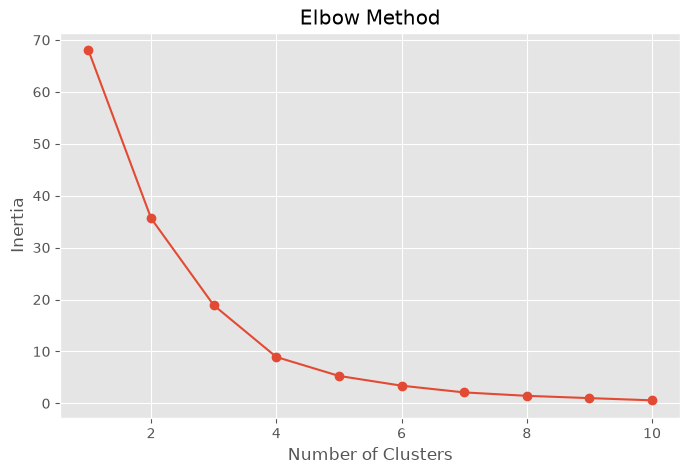

In [126]:
plt.figure(figsize=(8,5))

plt.plot(

    range(1,11),

    inertia,

    marker="o"

)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.savefig(
    "charts/elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Elbow Method Analysis

The Elbow Method was used to determine the optimal number of clusters for K-Means clustering.

A sharp decrease in inertia is observed from **1 to 4 clusters**, after which the rate of improvement becomes much smaller.

Therefore, **4 clusters** were selected as the optimal number of demand segments since adding more clusters provides only marginal improvement.

In [127]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(scaled)

cluster_df.head()

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster
0,Accessories,164186.7000,217.178175,337.723800,1.450560,1
1,Appliances,104618.4030,227.926804,378.006735,1.652429,2
2,Art,26705.4100,34.019631,60.301752,0.496495,2
3,Binders,200028.7850,134.067550,568.099970,0.657786,1
4,Bookcases,113813.1987,503.598224,641.419280,0.498466,2


In [128]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled)

In [129]:
cluster_df["PC1"] = pca_features[:,0]
cluster_df["PC2"] = pca_features[:,1]

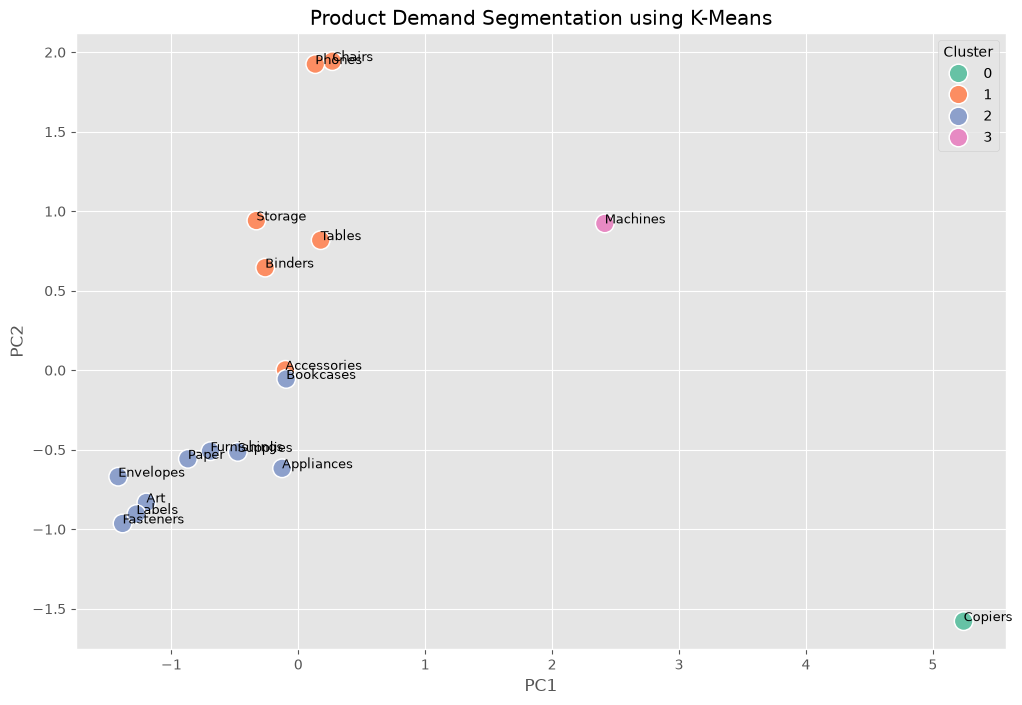

In [130]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=cluster_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=180
)

for i in range(len(cluster_df)):
    plt.text(
        cluster_df["PC1"].iloc[i],
        cluster_df["PC2"].iloc[i],
        cluster_df["Sub-Category"].iloc[i],
        fontsize=9
    )

plt.title("Product Demand Segmentation using K-Means")

plt.grid(True)

plt.savefig(
    "charts/product_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [131]:
cluster_df.sort_values("Cluster")

,Sub-Category,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,PC1,PC2
6,Copiers,146248.0940,2215.880212,3216.185499,4.797295,0,5.242690,-1.578112
0,Accessories,164186.7000,217.178175,337.723800,1.450560,1,-0.101749,0.002518
5,Chairs,322822.7310,531.833165,551.180296,0.209547,1,0.268112,1.943703
3,Binders,200028.7850,134.067550,568.099970,0.657786,1,-0.261117,0.645221
13,Phones,327782.4480,374.180877,494.390228,0.355576,1,0.133555,1.925136
14,Storage,219343.3920,263.633885,354.907482,0.383661,1,-0.330799,0.941511
16,Tables,202810.6280,645.893720,598.584981,0.330780,1,0.176016,0.818020
2,Art,26705.4100,34.019631,60.301752,0.496495,2,-1.197441,-0.831569
7,Envelopes,16128.0460,65.032444,85.170691,-0.121213,2,-1.419286,-0.669671
4,Bookcases,113813.1987,503.598224,641.419280,0.498466,2,-0.095392,-0.054950


In [132]:
cluster_summary = cluster_df.groupby("Cluster")[

    [
        "Total Sales",
        "Growth Rate",
        "Sales Volatility",
        "Average Order Value"
    ]

].mean()

cluster_summary.round(2)

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
Cluster,,,,
0,146248.09,4.80,3216.19,2215.88
1,239495.78,0.56,484.15,361.13
2,54341.71,0.59,268.57,142.75
3,189238.63,-0.30,2765.10,1645.55


In [133]:
cluster_df.sort_values("Cluster")

cluster_summary

,Total Sales,Growth Rate,Sales Volatility,Average Order Value
Cluster,,,,
0,146248.094000,4.797295,3216.185499,2215.880212
1,239495.780667,0.564652,484.147793,361.131228
2,54341.708189,0.587958,268.574395,142.746758
3,189238.631000,-0.297931,2765.102088,1645.553313


In [134]:
cluster_labels = {
    0: "High Growth Premium Products",
    1: "High Volume Stable Demand",
    2: "Low Volume Regular Demand",
    3: "Declining Premium Products"
}

cluster_df["Demand Segment"] = cluster_df["Cluster"].map(cluster_labels)

In [135]:
cluster_df[
    [
        "Sub-Category",
        "Demand Segment",
        "Total Sales",
        "Growth Rate"
    ]
].sort_values("Demand Segment")

,Sub-Category,Demand Segment,Total Sales,Growth Rate
11,Machines,Declining Premium Products,189238.6310,-0.297931
6,Copiers,High Growth Premium Products,146248.0940,4.797295
0,Accessories,High Volume Stable Demand,164186.7000,1.450560
3,Binders,High Volume Stable Demand,200028.7850,0.657786
5,Chairs,High Volume Stable Demand,322822.7310,0.209547
13,Phones,High Volume Stable Demand,327782.4480,0.355576
14,Storage,High Volume Stable Demand,219343.3920,0.383661
16,Tables,High Volume Stable Demand,202810.6280,0.330780
1,Appliances,Low Volume Regular Demand,104618.4030,1.652429
2,Art,Low Volume Regular Demand,26705.4100,0.496495


### Product Demand Segmentation

K-Means clustering divided the product sub-categories into four meaningful demand segments based on sales performance, growth rate, volatility, and average order value.

#### Cluster 0 – High Growth Premium Products
This cluster contains premium products with the highest growth rate, high average order value, and significant sales volatility. These products require close inventory monitoring because demand is increasing rapidly.

#### Cluster 1 – High Volume Stable Demand
This cluster represents the company's primary revenue-generating products. They exhibit high sales volume, consistent demand, and moderate volatility, making them suitable for regular inventory replenishment.

#### Cluster 2 – Low Volume Regular Demand
Products in this cluster generate relatively low sales and have lower average order values. Inventory should be maintained efficiently without excessive stock levels.

#### Cluster 3 – Declining Premium Products
This cluster contains expensive products experiencing declining demand. Businesses should monitor these items carefully, avoid overstocking, and reassess future purchasing decisions.

## Recommended Stocking Strategy

| Demand Segment | Recommended Strategy |
|----------------|----------------------|
| High Growth Premium Products | Increase inventory levels and closely monitor demand trends to avoid stock shortages. |
| High Volume Stable Demand | Maintain consistent stock levels using regular replenishment schedules. |
| Low Volume Regular Demand | Keep moderate inventory levels to minimize holding costs while meeting customer demand. |
| Declining Premium Products | Reduce inventory gradually and review pricing or promotional strategies to improve demand. |